# AttentionUNet — Salem Mineral Segmentation (Raw 7-Band Landsat-8)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1")
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1


### Imports & Reproducibility

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

import rasterio as rio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Albumentations for probabilistic augmentation
import albumentations as A

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
_g = torch.Generator()
_g.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
GPU    : Tesla T4


### Configuration

In [3]:
# ── Paths
BASE_DIR  = Path("/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1")
BASE_NAME = 'RAW_BANDS(7)'

RAW_NPY   = BASE_DIR / 'salem_multispectral_cropped_8.npy'    # (H, W, 7)
MASK_NPY  = BASE_DIR / 'salem_valid_mask_8.npy'               # (H, W) bool
LABEL_NPY = BASE_DIR / 'salem_Minerals_binary_labels_8.npy'
RAW_TIF   = BASE_DIR / 'salem_multispectral_cropped_8.tif'    # spatial metadata only

# ── Patch settings
PATCH_SIZE   = 128
STRIDE       = 32
NAN_THRESH   = 0.30

# ── Model
IN_CHANNELS  = 7
NUM_CLASSES  = 1        # binary segmentation

# ── Training
BATCH_SIZE   = 16
NUM_EPOCHS   = 120
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15     # explicit val split; test = 1 - TRAIN_SPLIT - VAL_SPLIT = 0.15

THRESHOLD    = 0.3

# ── Output dirs
PATCH_DIR    = BASE_DIR / 'patches_rawbands_final'
CKPT_PATH    = BASE_DIR / 'best_resunet_minerals_rawbands_final.pth'
RESULTS_DIR  = BASE_DIR / 'results_rawbands_final'

PATCH_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Raw-band configuration loaded.")
print(f"  Input channels : {IN_CHANNELS} (raw Landsat-8 bands)")
print(f"  Patch size     : {PATCH_SIZE}×{PATCH_SIZE}")
print(f"  Stride         : {STRIDE}")
print(f"  Train/Val/Test : {TRAIN_SPLIT}/{VAL_SPLIT}/{1-TRAIN_SPLIT-VAL_SPLIT:.2f}")
print(f"  Train threshold: {THRESHOLD}")

Raw-band configuration loaded.
  Input channels : 7 (raw Landsat-8 bands)
  Patch size     : 128×128
  Stride         : 32
  Train/Val/Test : 0.7/0.15/0.15
  Train threshold: 0.3


### Load Raw Bands + Valid Mask + Labels

In [4]:
print("Loading pre-saved raw-band arrays...")

# ── Load multispectral array
landsat_stack = np.load(RAW_NPY).astype(np.float32)

# Auto-detect and fix channel dimension order
if landsat_stack.ndim == 3 and landsat_stack.shape[0] == 7:
    print(f"  Detected channels-first format {landsat_stack.shape} to transposing to channels-last")
    landsat_stack = np.transpose(landsat_stack, (1, 2, 0))   # (7, H, W) → (H, W, 7)

print(f"  Raw-band stack shape : {landsat_stack.shape}")      # (H, W, 7)

# ── Load valid mask
valid_mask = np.load(MASK_NPY).astype(bool)                   # (H, W)
print(f"  Valid mask shape     : {valid_mask.shape}")

assert landsat_stack.shape[:2] == valid_mask.shape, (
    f"Shape mismatch! Stack {landsat_stack.shape[:2]} != mask {valid_mask.shape}"
)

# ── Apply valid mask: set invalid pixels to NaN
for b in range(landsat_stack.shape[-1]):
    landsat_stack[:, :, b][~valid_mask] = np.nan

H, W, C = landsat_stack.shape
print(f"\nRaw-band stack shape : {landsat_stack.shape}")
print(f"Valid pixels         : {np.sum(valid_mask):,} ({100*np.sum(valid_mask)/valid_mask.size:.2f}%)")

# ── Load spatial metadata from GeoTIFF (for future GeoTIFF export)
with rio.open(RAW_TIF) as src:
    landsat_transform = src.transform
    landsat_crs       = src.crs
    landsat_profile   = src.profile.copy()
    landsat_profile.update({'height': H, 'width': W, 'count': 1, 'transform': landsat_transform})
print("Spatial metadata loaded from GeoTIFF.")

# ── Load binary labels
binary_labels = np.load(LABEL_NPY).astype(np.uint8)           # (H, W)

if binary_labels.shape != valid_mask.shape:
    raise ValueError(
        f"Shape mismatch! Label {binary_labels.shape} vs mask {valid_mask.shape}."
    )

binary_labels[~valid_mask] = 0

# ── Class statistics
total_px   = int(np.sum(valid_mask))
mineral_px = int(np.sum((binary_labels == 1) & valid_mask))
bg_px      = total_px - mineral_px
ratio      = bg_px / (mineral_px + 1e-8)

print("\nAfter valid-mask application:")
print(f"  Valid pixels    : {total_px:,}")
print(f"  Mineral pixels  : {mineral_px:,} ({mineral_px/total_px*100:.4f}%)")
print(f"  Background px   : {bg_px:,}")
print(f"  Imbalance ratio : {ratio:.0f} : 1")

Loading pre-saved raw-band arrays...
  Detected channels-first format (7, 2455, 4327) to transposing to channels-last
  Raw-band stack shape : (2455, 4327, 7)
  Valid mask shape     : (2455, 4327)

Raw-band stack shape : (2455, 4327, 7)
Valid pixels         : 5,794,980 (54.55%)
Spatial metadata loaded from GeoTIFF.

After valid-mask application:
  Valid pixels    : 5,794,980
  Mineral pixels  : 2,309 (0.0398%)
  Background px   : 5,792,671
  Imbalance ratio : 2509 : 1


### Spatial Block Split + Patch Extraction (No Overlap)

In [5]:
import gc
from sklearn.model_selection import train_test_split

MIN_MINERAL_FRAC   = 0.001  # ≥0.5% mineral pixels → mineral patch
MAX_BG_RATIO       = 2      # max bg patches per mineral patch (per split)
NON_OVERLAP_STRIDE = 64     # 50% overlap

# ── Augmentation counts
N_AUG_MINERAL = 10   # each mineral patch → 10 augmented copies
N_AUG_BG      = 3   # each bg patch      → 3 augmented copies

print('PATCH EXTRACTION — Non-overlapping stride (zero leakage)')
print(f'  Patch size       : {PATCH_SIZE}×{PATCH_SIZE}')
print(f'  Stride           : {NON_OVERLAP_STRIDE}')
print(f'  Min mineral frac : {MIN_MINERAL_FRAC}  [FIX #6: raised from 0.001]')
print(f'  Mineral aug      : {N_AUG_MINERAL}× per patch (train only)')
print(f'  Background aug   : {N_AUG_BG}× per patch (train only)')

# ── Extract ALL valid patches with non-overlapping stride
H_img, W_img = landsat_stack.shape[:2]

all_mineral_imgs, all_mineral_lbls, all_mineral_valid, all_mineral_pos = [], [], [], []
all_bg_imgs,      all_bg_lbls,      all_bg_valid,      all_bg_pos      = [], [], [], []
total_candidates = skipped_nan = 0

for r in range(0, H_img - PATCH_SIZE + 1, NON_OVERLAP_STRIDE):
    for c in range(0, W_img - PATCH_SIZE + 1, NON_OVERLAP_STRIDE):
        total_candidates += 1
        img_p = landsat_stack[r:r+PATCH_SIZE, c:c+PATCH_SIZE, :].copy()
        lbl_p = binary_labels[r:r+PATCH_SIZE, c:c+PATCH_SIZE].copy()

        nan_frac = np.isnan(img_p).any(axis=-1).mean()
        if nan_frac > NAN_THRESH:
            skipped_nan += 1
            continue

        # Capture per-patch valid pixel mask BEFORE filling NaNs.
        valid_p = (~np.isnan(img_p).any(axis=-1)).astype(np.uint8)  # (H, W) uint8

        img_p = np.nan_to_num(img_p, nan=0.0)

        if lbl_p.mean() >= MIN_MINERAL_FRAC:
            all_mineral_imgs.append(img_p)
            all_mineral_lbls.append(lbl_p)
            all_mineral_valid.append(valid_p)
            all_mineral_pos.append((r, c))
        elif img_p.max() > 0:
            all_bg_imgs.append(img_p)
            all_bg_lbls.append(lbl_p)
            all_bg_valid.append(valid_p)
            all_bg_pos.append((r, c))

print(f'\nTotal candidates   : {total_candidates}')
print(f'Skipped (NaN>30%)  : {skipped_nan}')
print(f'Mineral patches    : {len(all_mineral_imgs)}')
print(f'Background patches : {len(all_bg_imgs)}')

if len(all_mineral_imgs) == 0:
    raise ValueError('No mineral patches found! Check MIN_MINERAL_FRAC or NAN_THRESH.')


# ── Stratified split of MINERAL patches
mineral_fracs = np.array([lbl.mean() for lbl in all_mineral_lbls])
strat_bins    = np.digitize(mineral_fracs, bins=[0.05, 0.15, 0.30, 0.50])

all_idx = np.arange(len(all_mineral_imgs))

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=(VAL_SPLIT + (1 - TRAIN_SPLIT - VAL_SPLIT)),
    stratify=strat_bins,
    random_state=SEED
)

temp_strat = strat_bins[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_strat,
    random_state=SEED
)

print(f'\nMineral patch split (stratified by mineral fraction):')
print(f'  Train : {len(train_idx):4d}  ({len(train_idx)/len(all_idx)*100:.1f}%)')
print(f'  Val   : {len(val_idx):4d}  ({len(val_idx)/len(all_idx)*100:.1f}%)')
print(f'  Test  : {len(test_idx):4d}  ({len(test_idx)/len(all_idx)*100:.1f}%)')


# ── Verify zero pixel overlap between splits
train_pos_set = set(all_mineral_pos[i] for i in train_idx)
val_pos_set   = set(all_mineral_pos[i] for i in val_idx)
test_pos_set  = set(all_mineral_pos[i] for i in test_idx)

assert len(train_pos_set & val_pos_set)  == 0, 'Train/Val mineral overlap!'
assert len(train_pos_set & test_pos_set) == 0, 'Train/Test mineral overlap!'
assert len(val_pos_set   & test_pos_set) == 0, 'Val/Test mineral overlap!'
print('\n Zero-overlap verified: no patch origin shared between any two splits.')


# ── Split background patches
rng    = np.random.default_rng(SEED)
bg_idx = rng.permutation(len(all_bg_imgs))

n_bg       = len(bg_idx)
n_bg_train = int(n_bg * TRAIN_SPLIT)
n_bg_val   = int(n_bg * VAL_SPLIT)

bg_train_idx = bg_idx[:n_bg_train]
bg_val_idx   = bg_idx[n_bg_train : n_bg_train + n_bg_val]
bg_test_idx  = bg_idx[n_bg_train + n_bg_val:]

def cap_bg(bg_indices, n_mineral, max_ratio, rng):
    max_bg = min(len(bg_indices), max(max_ratio, max_ratio * n_mineral))
    return rng.choice(bg_indices, size=int(max_bg), replace=False)

bg_train_idx = cap_bg(bg_train_idx, len(train_idx), MAX_BG_RATIO, rng)
bg_val_idx   = cap_bg(bg_val_idx,   len(val_idx),   MAX_BG_RATIO, rng)
bg_test_idx  = cap_bg(bg_test_idx,  len(test_idx),  MAX_BG_RATIO, rng)

print(f'\nBackground patches after cap (max {MAX_BG_RATIO}× mineral):')
print(f'  Train bg : {len(bg_train_idx)}')
print(f'  Val   bg : {len(bg_val_idx)}')
print(f'  Test  bg : {len(bg_test_idx)}')

split_data = {
    'train': {
        'mineral_imgs':   [all_mineral_imgs[i]   for i in train_idx],
        'mineral_lbls':   [all_mineral_lbls[i]   for i in train_idx],
        'mineral_valids': [all_mineral_valid[i]  for i in train_idx],
        'bg_imgs':        [all_bg_imgs[i]         for i in bg_train_idx],
        'bg_lbls':        [all_bg_lbls[i]         for i in bg_train_idx],
        'bg_valids':      [all_bg_valid[i]        for i in bg_train_idx],
    },
    'val': {
        'mineral_imgs':   [all_mineral_imgs[i]   for i in val_idx],
        'mineral_lbls':   [all_mineral_lbls[i]   for i in val_idx],
        'mineral_valids': [all_mineral_valid[i]  for i in val_idx],
        'bg_imgs':        [all_bg_imgs[i]         for i in bg_val_idx],
        'bg_lbls':        [all_bg_lbls[i]         for i in bg_val_idx],
        'bg_valids':      [all_bg_valid[i]        for i in bg_val_idx],
    },
    'test': {
        'mineral_imgs':   [all_mineral_imgs[i]   for i in test_idx],
        'mineral_lbls':   [all_mineral_lbls[i]   for i in test_idx],
        'mineral_valids': [all_mineral_valid[i]  for i in test_idx],
        'bg_imgs':        [all_bg_imgs[i]         for i in bg_test_idx],
        'bg_lbls':        [all_bg_lbls[i]         for i in bg_test_idx],
        'bg_valids':      [all_bg_valid[i]        for i in bg_test_idx],
    },
}

print('\n── Split summary (pre-augmentation) ──')
for sname, sd in split_data.items():
    n_min = len(sd['mineral_imgs'])
    n_bg  = len(sd['bg_imgs'])
    print(f'  {sname:5s} | mineral={n_min:4d} | bg={n_bg:4d} | total={n_min+n_bg}')

del all_mineral_imgs, all_mineral_lbls, all_mineral_pos
del all_bg_imgs, all_bg_lbls, all_bg_pos
gc.collect()


# ── Compute normalization stats from ORIGINAL train patches
band_names = ['B1 (Coastal)', 'B2 (Blue)', 'B3 (Green)', 'B4 (Red)',
              'B5 (NIR)', 'B6 (SWIR1)', 'B7 (SWIR2)']

tr_d = split_data['train']
orig_train_imgs = np.array(
    tr_d['mineral_imgs'] + tr_d['bg_imgs'], dtype=np.float32
)  # (N_orig, H, W, 7) — pre-augmentation

band_means_list, band_stds_list = [], []
print(f'\nComputing per-band stats from {len(orig_train_imgs)} ORIGINAL train patches...')
for c in range(IN_CHANNELS):
    vals = orig_train_imgs[:, :, :, c].ravel()
    vals = vals[np.isfinite(vals)]
    m    = float(vals.mean())
    s    = float(vals.std()) + 1e-8
    band_means_list.append(m)
    band_stds_list.append(s)
    print(f'  {band_names[c]:<20} | mean = {m:10.4f} | std = {s:10.4f}')

band_means = np.array(band_means_list, dtype=np.float32)
band_stds  = np.array(band_stds_list,  dtype=np.float32)
del orig_train_imgs
gc.collect()
print('Normalization stats computed from original (pre-augmentation) train patches.')


# ── Albumentations augmentation pipeline
_aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.GaussNoise(var_limit=(1e-6, 9e-6), p=0.3),  # very mild spectral noise
], additional_targets={'mask': 'mask', 'valid_mask': 'mask'})


def augment_patches(imgs, lbls, valids, n_augments, seed_offset=0):
    aug_imgs, aug_lbls, aug_valids = [], [], []
    for idx, (img, lbl, valid) in enumerate(zip(imgs, lbls, valids)):
        for k in range(n_augments):
            random.seed(SEED + seed_offset + idx * 100 + k)
            np.random.seed(SEED + seed_offset + idx * 100 + k)
            result  = _aug_pipeline(image=img, mask=lbl.astype(np.uint8),
                                    valid_mask=valid.astype(np.uint8))
            aug_imgs.append(result['image'].copy())
            aug_lbls.append(result['mask'].copy())
            aug_valids.append(result['valid_mask'].copy())
    return aug_imgs, aug_lbls, aug_valids


# ── Augment TRAIN mineral patches
n_orig_mineral = len(tr_d['mineral_imgs'])

aug_min_imgs, aug_min_lbls, aug_min_valids = augment_patches(
    tr_d['mineral_imgs'],
    tr_d['mineral_lbls'],
    tr_d['mineral_valids'],
    n_augments=N_AUG_MINERAL,
    seed_offset=0           # mineral aug seed space: 0 to 0 + n_mineral*100*8
)

tr_min_all_imgs   = list(tr_d['mineral_imgs'])   + aug_min_imgs
tr_min_all_lbls   = list(tr_d['mineral_lbls'])   + aug_min_lbls
tr_min_all_valids = list(tr_d['mineral_valids']) + aug_min_valids

print(f'\nAugmented train MINERAL patches (Albumentations, p=0.5 per transform):')
print(f'  Original : {n_orig_mineral}')
print(f'  Aug only : {len(aug_min_imgs)}  ({N_AUG_MINERAL} copies × {n_orig_mineral})')
print(f'  Total    : {len(tr_min_all_imgs)}  (orig + aug)')


# ── Augment TRAIN background patches
n_orig_bg = len(tr_d['bg_imgs'])

aug_bg_imgs, aug_bg_lbls, aug_bg_valids = augment_patches(
    tr_d['bg_imgs'],
    tr_d['bg_lbls'],
    tr_d['bg_valids'],
    n_augments=N_AUG_BG,
    seed_offset=10000       # separate seed space — no collision with mineral aug
)

tr_bg_all_imgs   = list(tr_d['bg_imgs'])   + aug_bg_imgs
tr_bg_all_lbls   = list(tr_d['bg_lbls'])   + aug_bg_lbls
tr_bg_all_valids = list(tr_d['bg_valids']) + aug_bg_valids

print(f'\nAugmented train BACKGROUND patches (Albumentations, p=0.5 per transform):')
print(f'  Original : {n_orig_bg}')
print(f'  Aug only : {len(aug_bg_imgs)}  ({N_AUG_BG} copies × {n_orig_bg})')
print(f'  Total    : {len(tr_bg_all_imgs)}  (orig + aug)')

del aug_min_imgs, aug_min_lbls, aug_min_valids, aug_bg_imgs, aug_bg_lbls, aug_bg_valids
gc.collect()


# ── Assemble final arrays
def assemble(min_imgs, min_lbls, min_valids, bg_imgs, bg_lbls, bg_valids):
    imgs   = np.concatenate([
        np.array(min_imgs,   dtype=np.float32),
        np.array(bg_imgs,    dtype=np.float32)
    ], axis=0)
    lbls   = np.concatenate([
        np.array(min_lbls,   dtype=np.uint8),
        np.array(bg_lbls,    dtype=np.uint8)
    ], axis=0)
    valids = np.concatenate([
        np.array(min_valids, dtype=np.uint8),
        np.array(bg_valids,  dtype=np.uint8)
    ], axis=0)
    return imgs, lbls, valids


train_imgs, train_lbls, train_valids = assemble(
    tr_min_all_imgs,   tr_min_all_lbls,   tr_min_all_valids,
    tr_bg_all_imgs,    tr_bg_all_lbls,    tr_bg_all_valids
)
val_imgs,   val_lbls,   val_valids   = assemble(
    split_data['val']['mineral_imgs'],   split_data['val']['mineral_lbls'],   split_data['val']['mineral_valids'],
    split_data['val']['bg_imgs'],        split_data['val']['bg_lbls'],        split_data['val']['bg_valids']
)
test_imgs,  test_lbls,  test_valids  = assemble(
    split_data['test']['mineral_imgs'],  split_data['test']['mineral_lbls'],  split_data['test']['mineral_valids'],
    split_data['test']['bg_imgs'],       split_data['test']['bg_lbls'],       split_data['test']['bg_valids']
)

del tr_min_all_imgs, tr_min_all_lbls, tr_min_all_valids
del tr_bg_all_imgs,  tr_bg_all_lbls,  tr_bg_all_valids
del split_data, tr_d
gc.collect()
gc.collect()


# ── Build tags and shuffle train
def make_tags(lbl_arr):
    N = len(lbl_arr)
    return (lbl_arr.reshape(N, -1).sum(axis=1) > 0).astype(np.uint8)

train_tags = make_tags(train_lbls)
val_tags   = make_tags(val_lbls)
test_tags  = make_tags(test_lbls)

perm         = np.random.default_rng(SEED).permutation(len(train_imgs))
train_imgs   = train_imgs[perm]
train_lbls   = train_lbls[perm]
train_valids = train_valids[perm]
train_tags   = train_tags[perm]

# ── Print final dataset summary
print('\n── Final dataset sizes ──')
print(f'  Train : {len(train_imgs):>5} patches | '
      f'mineral={train_tags.sum():>4} ({train_tags.mean()*100:.1f}%) | '
      f'bg={len(train_imgs)-train_tags.sum()}')
print(f'  Val   : {len(val_imgs):>5} patches | '
      f'mineral={val_tags.sum():>4} ({val_tags.mean()*100:.1f}%) | '
      f'bg={len(val_imgs)-val_tags.sum()}')
print(f'  Test  : {len(test_imgs):>5} patches | '
      f'mineral={test_tags.sum():>4} ({test_tags.mean()*100:.1f}%) | '
      f'bg={len(test_imgs)-test_tags.sum()}')

print(f'\n  Train breakdown:')
print(f'    Mineral patches : {n_orig_mineral} orig + {n_orig_mineral * N_AUG_MINERAL} aug = {n_orig_mineral * (1 + N_AUG_MINERAL)}')
print(f'    Background patches : {n_orig_bg} orig + {n_orig_bg * N_AUG_BG} aug = {n_orig_bg * (1 + N_AUG_BG)}')
print(f'\n  Val and Test : ONLY original unaugmented patches from non-overlapping splits.')

# ── Save arrays
PATCH_DIR.mkdir(exist_ok=True)
np.save(PATCH_DIR / 'train_imgs_rawbands.npy',   train_imgs)
np.save(PATCH_DIR / 'train_lbls_rawbands.npy',   train_lbls)
np.save(PATCH_DIR / 'train_valids_rawbands.npy', train_valids)
np.save(PATCH_DIR / 'val_imgs_rawbands.npy',     val_imgs)
np.save(PATCH_DIR / 'val_lbls_rawbands.npy',     val_lbls)
np.save(PATCH_DIR / 'val_valids_rawbands.npy',   val_valids)
np.save(PATCH_DIR / 'test_imgs_rawbands.npy',    test_imgs)
np.save(PATCH_DIR / 'test_lbls_rawbands.npy',    test_lbls)
np.save(PATCH_DIR / 'test_valids_rawbands.npy',  test_valids)
np.save(PATCH_DIR / 'rawbands_means.npy', band_means)
np.save(PATCH_DIR / 'rawbands_stds.npy',  band_stds)
print('\nAll arrays and normalization stats saved.')

PATCH EXTRACTION — Non-overlapping stride (zero leakage)
  Patch size       : 128×128
  Stride           : 64
  Min mineral frac : 0.001  [FIX #6: raised from 0.001]
  Mineral aug      : 10× per patch (train only)
  Background aug   : 3× per patch (train only)

Total candidates   : 2442
Skipped (NaN>30%)  : 1126
Mineral patches    : 127
Background patches : 1189

Mineral patch split (stratified by mineral fraction):
  Train :   88  (69.3%)
  Val   :   19  (15.0%)
  Test  :   20  (15.7%)

 Zero-overlap verified: no patch origin shared between any two splits.

Background patches after cap (max 2× mineral):
  Train bg : 176
  Val   bg : 38
  Test  bg : 40

── Split summary (pre-augmentation) ──
  train | mineral=  88 | bg= 176 | total=264
  val   | mineral=  19 | bg=  38 | total=57
  test  | mineral=  20 | bg=  40 | total=60

Computing per-band stats from 264 ORIGINAL train patches...
  B1 (Coastal)         | mean =     0.0334 | std =     0.0154
  B2 (Blue)            | mean =     0.0428 

### Dataset & DataLoaders

In [6]:
class MineralDataset(Dataset):
    def __init__(self, images, labels, valids, band_means, band_stds):
        self.images = images
        self.labels = labels
        self.valids = valids
        self.means  = band_means.reshape(1, 1, -1)
        self.stds   = band_stds.reshape(1, 1, -1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image = self.images[i].astype(np.float32).copy()
        label = self.labels[i].astype(np.float32).copy()
        valid = self.valids[i].astype(np.float32).copy()
        image = (image - self.means) / self.stds
        img_t   = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        lbl_t   = torch.from_numpy(label).unsqueeze(0).contiguous().float()
        valid_t = torch.from_numpy(valid).unsqueeze(0).contiguous().float()
        return img_t, lbl_t, valid_t


train_ds = MineralDataset(train_imgs, train_lbls, train_valids, band_means, band_stds)
val_ds   = MineralDataset(val_imgs,   val_lbls,   val_valids,   band_means, band_stds)
test_ds  = MineralDataset(test_imgs,  test_lbls,  test_valids,  band_means, band_stds)

train_gen = torch.Generator()
train_gen.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=train_gen)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'DataLoaders ready:')
print(f'  Train : {len(train_ds)} patches')
print(f'  Val   : {len(val_ds)} patches')
print(f'  Test  : {len(test_ds)} patches')

img_b, lbl_b, val_b = next(iter(train_loader))
print(f'  Batch image shape : {img_b.shape}')
print(f'  Batch label shape : {lbl_b.shape}')
print(f'  Batch valid shape : {val_b.shape}  (1=real pixel, 0=invalid border)')
del img_b, lbl_b, val_b
gc.collect()

DataLoaders ready:
  Train : 1672 patches
  Val   : 57 patches
  Test  : 60 patches
  Batch image shape : torch.Size([16, 7, 128, 128])
  Batch label shape : torch.Size([16, 1, 128, 128])
  Batch valid shape : torch.Size([16, 1, 128, 128])  (1=real pixel, 0=invalid border)


0

### Attention UNet Architecture

In [7]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )
        self.drop = nn.Dropout2d(p=dropout_p) if dropout_p > 0.0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.block(x))


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, int_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, int_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(int_ch)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, int_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(int_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(int_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g_up = F.interpolate(self.W_g(g), size=x.shape[2:],
                             mode='bilinear', align_corners=False)
        att  = self.relu(g_up + self.W_x(x))
        att  = self.psi(att)
        return x * att


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch, dropout_p=dropout_p)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        feat   = self.conv(x)
        pooled = self.pool(feat)
        return feat, pooled


class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.att  = AttentionGate(
            g_ch    = out_ch,
            x_ch    = skip_ch,
            int_ch  = max(out_ch // 2, 16)
        )
        self.conv = DoubleConv(out_ch + skip_ch, out_ch, dropout_p=dropout_p)

    def forward(self, x, skip):
        x    = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        skip = self.att(g=x, x=skip)
        x    = torch.cat([x, skip], dim=1)
        return self.conv(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=7, features=[32, 64, 128, 256, 512]):
        super().__init__()
        # ── Encoder:
        self.enc1   = EncoderBlock(in_channels, features[0])
        self.enc2   = EncoderBlock(features[0], features[1])
        self.enc3   = EncoderBlock(features[1], features[2], dropout_p=0.1)
        self.enc4   = EncoderBlock(features[2], features[3], dropout_p=0.2)
        # ── Bottleneck
        self.bridge = DoubleConv(features[3], features[4], dropout_p=0.2)
        # ── Decoder:
        self.dec4   = AttentionDecoderBlock(features[4], features[3], features[3])
        self.dec3   = AttentionDecoderBlock(features[3], features[2], features[2])
        self.dec2   = AttentionDecoderBlock(features[2], features[1], features[1])
        self.dec1   = AttentionDecoderBlock(features[1], features[0], features[0], dropout_p=0.1)
        # ── Output
        self.out    = nn.Conv2d(features[0], 1, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1, x = self.enc1(x)
        s2, x = self.enc2(x)
        s3, x = self.enc3(x)
        s4, x = self.enc4(x)
        x     = self.bridge(x)
        x     = self.dec4(x, s4)
        x     = self.dec3(x, s3)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.out(x)


# ── Instantiate
model = AttentionUNet(in_channels=IN_CHANNELS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
att_params   = sum(p.numel() for n, p in model.named_parameters() if 'att' in n)
print(f"Model             : Attention U-Net  (matched to UNet scale)")
print(f"Total Parameters  : {total_params:,}")
print(f"Attention params  : {att_params:,}  ({att_params/total_params*100:.1f}% overhead)")
print(f"Encoder dropout   : enc3=0.1 | enc4=0.2")
print(f"Bridge dropout    : 0.2")
print(f"Decoder dropout   : dec1=0.05 | dec2/3/4=0.0")
print(f"Attention int_ch  : dec4={max(256//2,16)} | dec3={max(128//2,16)} | dec2={max(64//2,16)} | dec1={max(32//2,16)}")

with torch.no_grad():
    dummy = torch.zeros(2, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Forward pass OK   : {dummy.shape} → {out.shape}")

Model             : Attention U-Net  (matched to UNet scale)
Total Parameters  : 7,852,441
Attention params  : 88,248  (1.1% overhead)
Encoder dropout   : enc3=0.1 | enc4=0.2
Bridge dropout    : 0.2
Decoder dropout   : dec1=0.05 | dec2/3/4=0.0
Attention int_ch  : dec4=128 | dec3=64 | dec2=32 | dec1=16
Forward pass OK   : torch.Size([2, 7, 128, 128]) → torch.Size([2, 1, 128, 128])


### Loss Function (Weighted BCE + Dice)

In [8]:
class BCEDiceLoss(nn.Module):
    def __init__(self, pos_weight=45.0, bce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super().__init__()
        self.register_buffer('pos_weight', torch.tensor([pos_weight], dtype=torch.float32))
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.smooth      = smooth

    def forward(self, logits, targets, valid_mask=None):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()

        # Masked BCE: zero out invalid pixels, average over valid only
        pw = self.pos_weight.expand_as(targets)
        bce_raw = F.binary_cross_entropy_with_logits(
            logits, targets, weight=None, reduction='none', pos_weight=pw
        )
        if valid_mask is not None:
            bce_loss = (bce_raw * valid_mask).sum() / (valid_mask.sum() + 1e-8)
        else:
            bce_loss = bce_raw.mean()

        # Masked Dice: restrict sums to valid pixels only
        probs = torch.sigmoid(logits)
        dims  = (1, 2, 3)
        if valid_mask is not None:
            probs_v   = probs   * valid_mask
            targets_v = targets * valid_mask
        else:
            probs_v   = probs
            targets_v = targets

        intersection = (probs_v * targets_v).sum(dims)
        cardinality  = probs_v.sum(dims) + targets_v.sum(dims)
        dice_loss    = 1.0 - ((2.0 * intersection + self.smooth) /
                               (cardinality + self.smooth)).mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


criterion = BCEDiceLoss(pos_weight=45.0, bce_weight=0.5, dice_weight=0.5).to(DEVICE)
print("Loss: Weighted BCE + Dice  (pos_weight=40, bce=0.5, dice=0.5)")
print("Note: Lower pos_weight → better Precision/Recall balance; less over-prediction of mineral class.")


Loss: Weighted BCE + Dice  (pos_weight=40, bce=0.5, dice=0.5)
Note: Lower pos_weight → better Precision/Recall balance; less over-prediction of mineral class.


### Metrics


In [9]:
class RunningMetrics:
    """Accumulates TP/FP/FN/TN counts across batches — O(1) memory."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
        self.total_loss = 0.0
        self.n_batches  = 0

    def update(self, preds_bin, targets, valid_mask=None, loss_val=0.0):
        p = preds_bin.reshape(-1).astype(np.int32)
        t = targets.reshape(-1).astype(np.int32)
        # Restrict counting to valid pixels only
        if valid_mask is not None:
            v = valid_mask.reshape(-1).astype(bool)
            p, t = p[v], t[v]
        self.tp += int(((p == 1) & (t == 1)).sum())
        self.fp += int(((p == 1) & (t == 0)).sum())
        self.fn += int(((p == 0) & (t == 1)).sum())
        self.tn += int(((p == 0) & (t == 0)).sum())
        self.total_loss += loss_val
        self.n_batches  += 1

    def compute(self, smooth=1e-8):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        precision   = (tp + smooth) / (tp + fp + smooth)
        recall      = (tp + smooth) / (tp + fn + smooth)
        f1          = 2 * precision * recall / (precision + recall + smooth)
        mineral_iou = (tp + smooth) / (tp + fp + fn + smooth)
        bg_iou      = (tn + smooth) / (tn + fp + fn + smooth)
        mean_iou    = (mineral_iou + bg_iou) / 2
        pixel_acc   = (tp + tn) / (tp + fp + fn + tn + smooth)
        avg_loss    = self.total_loss / max(self.n_batches, 1)
        return avg_loss, float(pixel_acc), float(mean_iou), float(mineral_iou), \
               float(precision), float(recall), float(f1)


def evaluate_efficient(model, loader, criterion, threshold, device=DEVICE):
    """Validation / test loop — no list accumulation, O(1) extra memory."""
    model.eval()
    metrics = RunningMetrics()

    with torch.no_grad():
        for imgs, lbls, valids in loader:
            imgs   = imgs.to(device)
            lbls   = lbls.to(device)
            valids = valids.to(device)

            logits    = model(imgs)
            loss      = criterion(logits, lbls, valids)
            probs     = torch.sigmoid(logits)
            preds_bin = (probs > threshold).float()

            metrics.update(
                preds_bin.cpu().numpy(),
                lbls.cpu().numpy(),
                valids.cpu().numpy(),
                loss.item()
            )

            del imgs, lbls, valids, logits, probs, preds_bin
            torch.cuda.empty_cache()

    return metrics.compute()


print("Metrics defined. Primary metric: Mineral IoU")

Metrics defined. Primary metric: Mineral IoU


### Optimizer & Scheduler

In [10]:
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)

scheduler = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

print("Optimizer : AdamW  (lr=5e-4, weight_decay=1e-4)")
print("Scheduler : ReduceLROnPlateau (monitoring val Mineral IoU)")

Optimizer : AdamW  (lr=5e-4, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (monitoring val Mineral IoU)


### Training Loop


In [11]:
import gc

print("Running pre-training threshold calibration on validation set...")

BEST_THRESHOLD = THRESHOLD
print(f"  Initial BEST_THRESHOLD = {BEST_THRESHOLD:.2f}  (will be refined after training)")

# ── Training loop
history = {
    'train_loss': [], 'val_loss': [],
    'train_miou': [], 'val_miou': [],
    'train_min_iou': [], 'val_min_iou': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [],    'val_recall': [],
    'train_f1': [],        'val_f1': []
}

best_val_mineral_iou = 0.0
patience_count       = 0
EARLY_STOP           = 20

gc.collect()
torch.cuda.empty_cache()

print(f"Training Attention UNet (Raw 7-Band) | Device: {DEVICE}")
print(f"Primary metric: Mineral IoU  |  Monitoring threshold: {THRESHOLD}")

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train phase
    model.train()
    train_metrics = RunningMetrics()

    loop = tqdm(train_loader,
                desc=f"Ep {epoch:3d}/{NUM_EPOCHS} [Train]",
                leave=False, ncols=100)

    for imgs, lbls, valids in loop:
        imgs   = imgs.to(DEVICE)
        lbls   = lbls.to(DEVICE)
        valids = valids.to(DEVICE)

        optimizer.zero_grad()

        logits = model(imgs)                          # single tensor — no aux heads
        loss   = criterion(logits, lbls, valids)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_val = loss.item()

        with torch.no_grad():
            probs     = torch.sigmoid(logits)
            preds_bin = (probs > THRESHOLD).float()
            train_metrics.update(
                preds_bin.cpu().numpy(),
                lbls.cpu().numpy(),
                valids.cpu().numpy(),
                loss_val
            )

        del imgs, lbls, valids, logits, probs, preds_bin, loss
        torch.cuda.empty_cache()

        loop.set_postfix(loss=f"{loss_val:.4f}")

    (train_loss, t_acc, t_miou,
     t_min_iou, t_precision, t_recall, t_f1) = train_metrics.compute()

    # ── Validation phase
    (val_loss, v_acc, v_miou,
     v_min_iou, v_precision, v_recall, v_f1) = evaluate_efficient(
        model, val_loader, criterion,
        threshold=THRESHOLD, device=DEVICE
    )

    scheduler.step(v_min_iou)

    # ── Log history
    history['train_loss'].append(train_loss);       history['val_loss'].append(val_loss)
    history['train_miou'].append(t_miou);           history['val_miou'].append(v_miou)
    history['train_min_iou'].append(t_min_iou);     history['val_min_iou'].append(v_min_iou)
    history['train_precision'].append(t_precision); history['val_precision'].append(v_precision)
    history['train_recall'].append(t_recall);       history['val_recall'].append(v_recall)
    history['train_f1'].append(t_f1);               history['val_f1'].append(v_f1)

    print(
        f"Ep {epoch:3d} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"MinIoU {t_min_iou*100:.2f}%/{v_min_iou*100:.2f}% | "
        f"Prec {v_precision*100:.2f}% | "
        f"Rec {v_recall*100:.2f}% | "
        f"F1 {v_f1*100:.2f}%"
    )

    # ── Checkpoint
    if v_min_iou > best_val_mineral_iou:
        best_val_mineral_iou = v_min_iou
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"   ✓ Best model saved (Val MinIoU={v_min_iou*100:.2f}% @ thr={THRESHOLD})")
        patience_count = 0
    else:
        patience_count += 1
        print(f"   [Patience {patience_count}/{EARLY_STOP}]")
        if patience_count >= EARLY_STOP:
            print("\nEarly stopping triggered.")
            break

    gc.collect()
    torch.cuda.empty_cache()

print(f"\nBest Validation Mineral IoU (@ thr={THRESHOLD}): {best_val_mineral_iou*100:.2f}%")

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print("Best checkpoint reloaded.")

Running pre-training threshold calibration on validation set...
  Initial BEST_THRESHOLD = 0.30  (will be refined after training)
Training Attention UNet (Raw 7-Band) | Device: cuda
Primary metric: Mineral IoU  |  Monitoring threshold: 0.3


Ep   1 | Loss 0.7937/0.6226 | MinIoU 0.27%/0.00% | Prec 0.00% | Rec 0.00% | F1 0.00%
   ✓ Best model saved (Val MinIoU=0.00% @ thr=0.3)


Ep   2 | Loss 0.7139/0.6172 | MinIoU 0.33%/1.21% | Prec 1.42% | Rec 7.58% | F1 2.39%
   ✓ Best model saved (Val MinIoU=1.21% @ thr=0.3)


Ep   3 | Loss 0.6955/0.6077 | MinIoU 0.53%/1.86% | Prec 2.09% | Rec 14.40% | F1 3.65%
   ✓ Best model saved (Val MinIoU=1.86% @ thr=0.3)


Ep   4 | Loss 0.6834/0.6080 | MinIoU 0.74%/2.83% | Prec 3.28% | Rec 17.31% | F1 5.51%
   ✓ Best model saved (Val MinIoU=2.83% @ thr=0.3)


...

Ep  98 | Loss 0.2241/0.4320 | MinIoU 90.94%/75.90% | Prec 88.56% | Rec 84.14% | F1 86.30%
   [Patience 16/20]


Ep  99 | Loss 0.2225/0.4291 | MinIoU 90.50%/76.91% | Prec 89.23% | Rec 84.78% | F1 86.95%
   [Patience 17/20]


Ep 100 | Loss 0.2280/0.4269 | MinIoU 88.71%/76.92% | Prec 88.49% | Rec 85.47% | F1 86.95%
   [Patience 18/20]


Ep 101 | Loss 0.2250/0.4288 | MinIoU 90.92%/76.55% | Prec 88.55% | Rec 84.97% | F1 86.72%
   [Patience 19/20]


Ep 102 | Loss 0.2262/0.4916 | MinIoU 89.71%/64.30% | Prec 95.20% | Rec 66.46% | F1 78.27%
   [Patience 20/20]

Early stopping triggered.

Best Validation Mineral IoU (@ thr=0.3): 77.78%
Best checkpoint reloaded.


### Training Curves

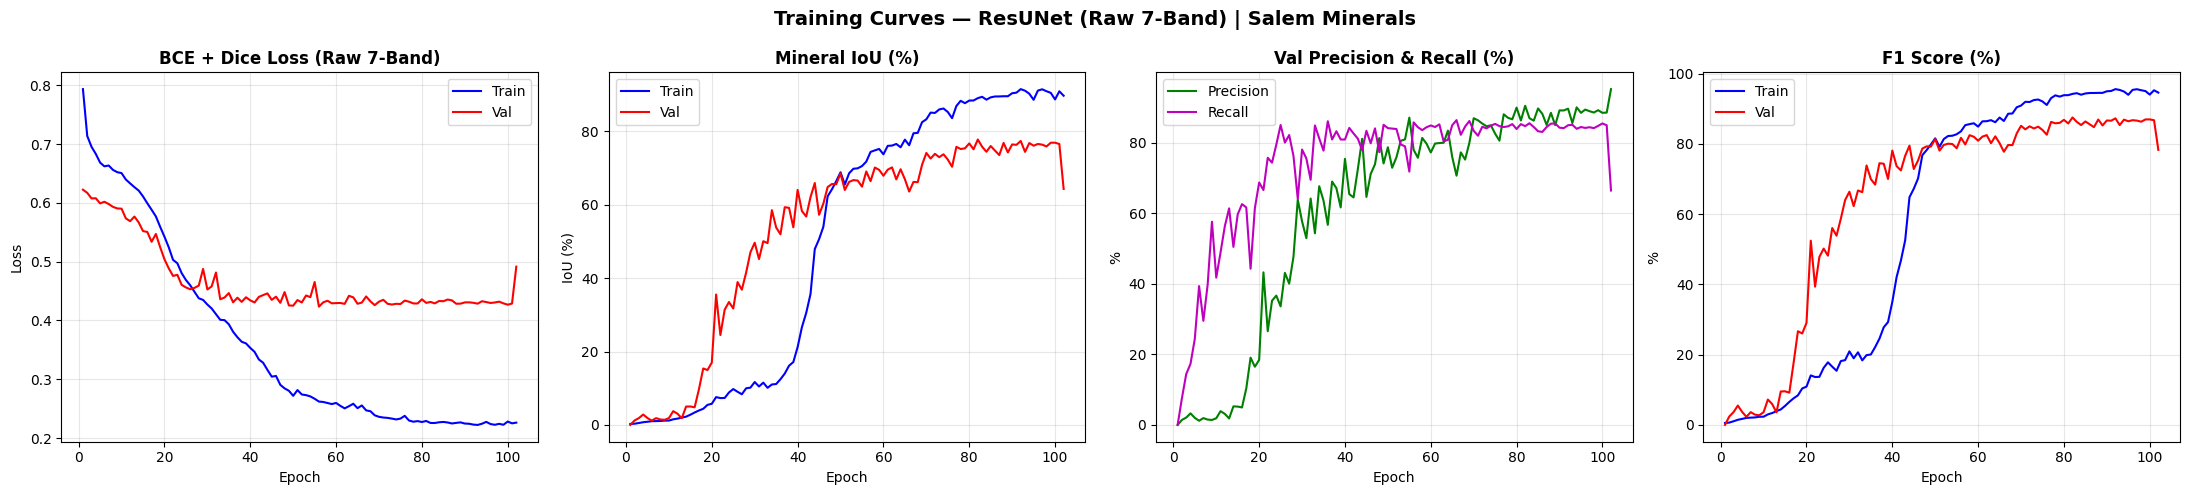

In [12]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0].plot(ep, history['val_loss'],   'r-', label='Val')
axes[0].set_title('BCE + Dice Loss (Raw 7-Band)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [v*100 for v in history['train_min_iou']], 'b-', label='Train')
axes[1].plot(ep, [v*100 for v in history['val_min_iou']],   'r-', label='Val')
axes[1].set_title('Mineral IoU (%)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [v*100 for v in history['val_precision']], 'g-', label='Precision')
axes[2].plot(ep, [v*100 for v in history['val_recall']],    'm-', label='Recall')
axes[2].set_title('Val Precision & Recall (%)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('%')
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(ep, [v*100 for v in history['train_f1']], 'b-', label='Train')
axes[3].plot(ep, [v*100 for v in history['val_f1']],   'r-', label='Val')
axes[3].set_title('F1 Score (%)', fontweight='bold')
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('%')
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle('Training Curves — AttentionUNet (Raw 7-Band) | Salem Minerals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_rawbands.png', dpi=150, bbox_inches='tight')
plt.show()

### Threshold Search on Validation Set

In [13]:
# No threshold search — use the same threshold as training
BEST_THRESHOLD = THRESHOLD
print(f"Using fixed training threshold: BEST_THRESHOLD = {BEST_THRESHOLD:.2f}")

Using fixed training threshold: BEST_THRESHOLD = 0.30


### Test Set Evaluation

In [14]:
# ── Results at FIXED threshold (baseline, no val-set optimisation)
(fix_loss, fix_acc, fix_miou, fix_min_iou,
 fix_precision, fix_recall, fix_f1) = evaluate_efficient(
    model, test_loader, criterion,
    threshold=THRESHOLD, device=DEVICE
)

print(" TEST SET RESULTS — Raw 7-Band AttentionUNet")

print(f"\n── At FIXED threshold = {THRESHOLD:.2f}  [Baseline — no val optimisation] ──")
print(f"  ★ Mineral IoU (PRIMARY) : {fix_min_iou*100:.2f}%")
print(f"  ★ F1 Score   (PRIMARY)  : {fix_f1*100:.2f}%")
print(f"  ★ Recall                : {fix_recall*100:.2f}%")
print(f"  ★ Precision             : {fix_precision*100:.2f}%")
print(f"    Mean IoU  (secondary) : {fix_miou*100:.2f}%")
print(f"    Loss                  : {fix_loss:.4f}")
print(f"    Pixel Acc (secondary,")
print(f"    background-dominated) : {fix_acc*100:.2f}%  ← misleading for imbalanced data")

 TEST SET RESULTS — Raw 7-Band UNet

── At FIXED threshold = 0.30  [Baseline — no val optimisation] ──
  ★ Mineral IoU (PRIMARY) : 82.61%
  ★ F1 Score   (PRIMARY)  : 90.47%
  ★ Recall                : 88.25%
  ★ Precision             : 92.81%
    Mean IoU  (secondary) : 91.29%
    Loss                  : 0.3969
    Pixel Acc (secondary,
    background-dominated) : 99.98%  ← misleading for imbalanced data


### Visualize Test Patch Predictions

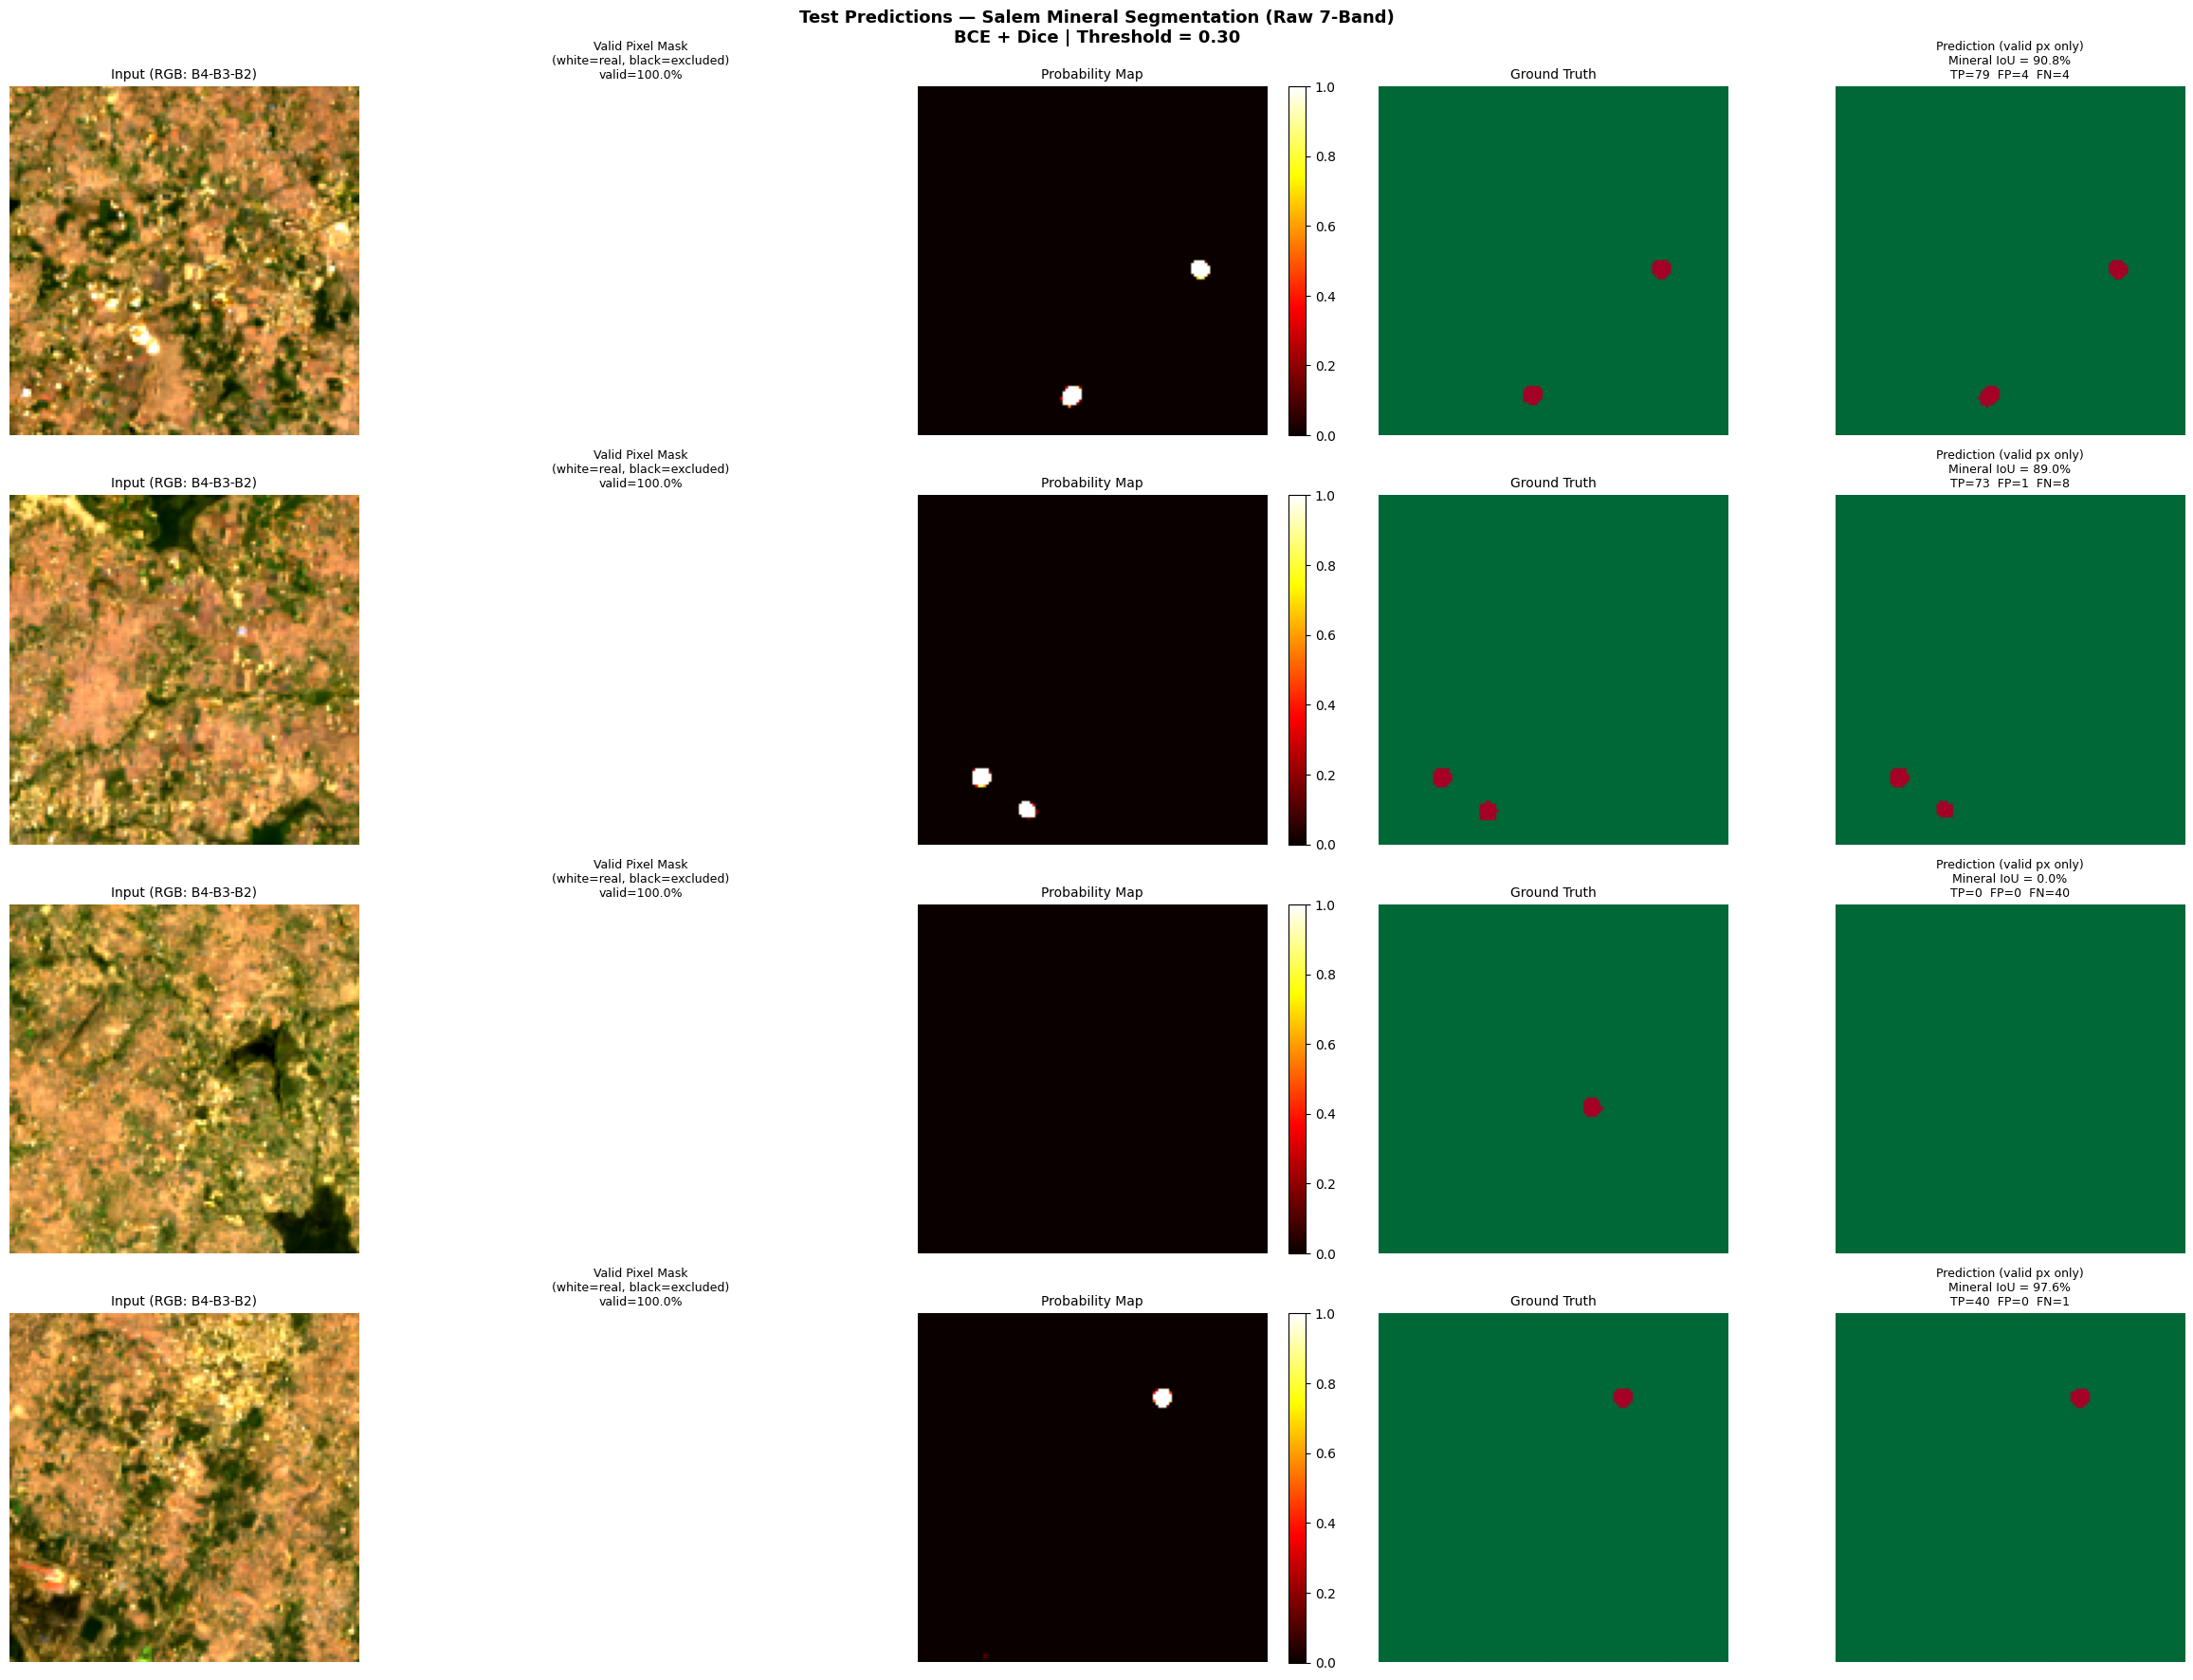

In [15]:
# Find mineral patches in the test set
mineral_test_idx = [
    i for i in range(len(test_ds))
    if test_ds.labels[i].sum() > 0
]

n_show = min(4, len(mineral_test_idx))
if n_show == 0:
    print("No mineral patches in test set to visualize.")
else:
    sample = random.sample(mineral_test_idx, n_show)
    # 5 columns: Input | Valid Mask | Probability Map | Ground Truth | Prediction
    fig, axes = plt.subplots(n_show, 5, figsize=(24, n_show * 4.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    model.eval()
    for row, i in enumerate(sample):
        img_t, lbl_t, valid_t = test_ds[i]
        img_t = img_t.to(DEVICE)

        with torch.no_grad():
            logits = model(img_t.unsqueeze(0))
            prob   = torch.sigmoid(logits).squeeze().cpu().numpy()

        pred_bin = (prob > BEST_THRESHOLD).astype(np.uint8)
        lbl_np   = lbl_t.squeeze().cpu().numpy()
        valid_np = valid_t.squeeze().numpy().astype(bool)

        # Undo normalization → make RGB from bands B4, B3, B2 (Red, Green, Blue)
        img_np  = img_t.cpu().permute(1, 2, 0).numpy() * band_stds + band_means
        rgb_vis = img_np[:, :, [3, 2, 1]]
        p2, p98 = np.percentile(rgb_vis, (2, 98))
        rgb_vis = np.clip((rgb_vis - p2) / (p98 - p2 + 1e-8), 0, 1)

        # Col 0: Input image
        axes[row, 0].imshow(rgb_vis)
        axes[row, 0].set_title("Input (RGB: B4-B3-B2)", fontsize=10)
        axes[row, 0].axis("off")

        # Col 1: Valid pixel mask
        axes[row, 1].imshow(valid_np, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title(
            f"Valid Pixel Mask\n(white=real, black=excluded)\nvalid={valid_np.mean()*100:.1f}%",
            fontsize=9
        )
        axes[row, 1].axis("off")

        # Col 2: Probability map
        im = axes[row, 2].imshow(prob, cmap="hot", vmin=0, vmax=1)
        axes[row, 2].set_title("Probability Map", fontsize=10)
        axes[row, 2].axis("off")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

        # Col 3: Ground truth
        axes[row, 3].imshow(lbl_np, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[row, 3].set_title("Ground Truth", fontsize=10)
        axes[row, 3].axis("off")

        # Col 4: Prediction — IoU computed on valid pixels only
        p_v = pred_bin[valid_np]
        t_v = lbl_np[valid_np].astype(np.uint8)
        tp_p = int(((p_v == 1) & (t_v == 1)).sum())
        fp_p = int(((p_v == 1) & (t_v == 0)).sum())
        fn_p = int(((p_v == 0) & (t_v == 1)).sum())
        iou_p = tp_p / (tp_p + fp_p + fn_p + 1e-8)

        axes[row, 4].imshow(pred_bin, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[row, 4].set_title(
            f"Prediction (valid px only)\nMineral IoU = {iou_p*100:.1f}%\nTP={tp_p}  FP={fp_p}  FN={fn_p}",
            fontsize=9
        )
        axes[row, 4].axis("off")

    plt.suptitle(
        f"Test Predictions — Salem Mineral Segmentation (Raw 7-Band)\n"
        f"BCE + Dice | Threshold = {BEST_THRESHOLD:.2f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "test_mineral_patches_rawbands.png", dpi=150, bbox_inches="tight")
    plt.show()

### Confusion Matrices — Train, Val & Test

  26,938,662 / 27,394,048 pixels used (98.3% valid, 455,386 border excluded)
  918,171 / 933,888 pixels used (98.3% valid, 15,717 border excluded)
  976,662 / 983,040 pixels used (99.4% valid, 6,378 border excluded)
 CONFUSION MATRIX REPORT — Raw 7-Band ResUNet
 Threshold = 0.30

── TRAIN SET (26,938,662 pixels total) ──
                            Predicted BG   Predicted Mineral
  True BG                   TN=  26,865,854   FP=       6,742
  True Mineral              FN=          25   TP=      66,041

  Accuracy    : 99.9749%
  Precision   : 90.7368%
  Recall      : 99.9622%
  Specificity : 99.9749%
  F1 Score    : 95.1264%
  Mineral IoU : 90.7057%
  Mean IoU    : 95.3403%

── VAL SET (918,171 pixels total) ──
                            Predicted BG   Predicted Mineral
  True BG                   TN=     916,447   FP=         141
  True Mineral              FN=         242   TP=       1,341

  Accuracy    : 99.9583%
  Precision   : 90.4858%
  Recall      : 84.7126%
  Specificity : 9

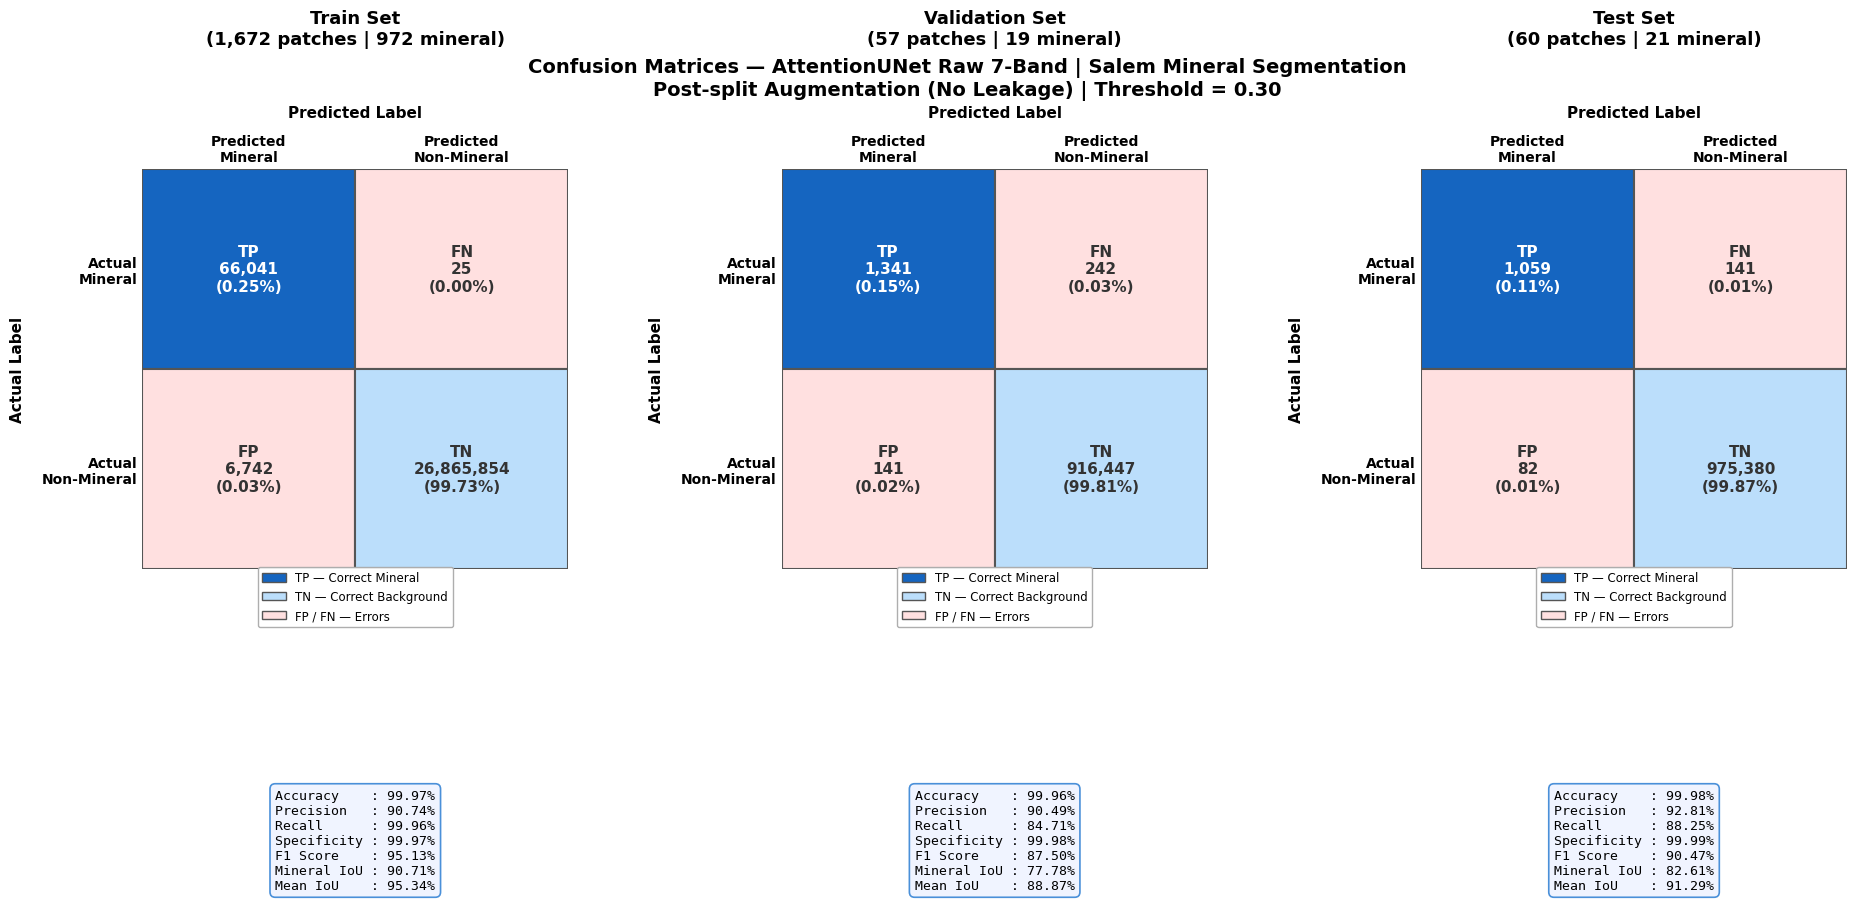


Saved: /content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1/results_rawbands_final/confusion_matrices_all_splits.png


In [16]:
import matplotlib.ticker as mticker

def collect_confusion(model, loader, threshold, device):
    """Accumulate TP/FP/FN/TN over an entire dataloader — valid pixels only."""
    model.eval()
    tp = fp = fn = tn = 0
    total_px = valid_px = 0

    with torch.no_grad():
        for imgs, lbls, valids in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            probs     = torch.sigmoid(model(imgs))
            preds_bin = (probs > threshold).float()

            p = preds_bin.cpu().numpy().reshape(-1).astype(np.int32)
            t = lbls.cpu().numpy().reshape(-1).astype(np.int32)
            v = valids.cpu().numpy().reshape(-1).astype(bool)

            total_px += len(v)
            valid_px += int(v.sum())

            # Restrict counts to valid pixels only
            p, t = p[v], t[v]

            tp += int(((p == 1) & (t == 1)).sum())
            fp += int(((p == 1) & (t == 0)).sum())
            fn += int(((p == 0) & (t == 1)).sum())
            tn += int(((p == 0) & (t == 0)).sum())

            del imgs, lbls, valids, probs, preds_bin
            torch.cuda.empty_cache()

    print(f"  {valid_px:,} / {total_px:,} pixels used "
          f"({valid_px/total_px*100:.1f}% valid, {total_px-valid_px:,} border excluded)")
    return tp, fp, fn, tn


def metrics_from_cm(tp, fp, fn, tn, smooth=1e-8):
    precision   = (tp + smooth) / (tp + fp + smooth)
    recall      = (tp + smooth) / (tp + fn + smooth)
    f1          = 2 * precision * recall / (precision + recall + smooth)
    mineral_iou = (tp + smooth) / (tp + fp + fn + smooth)
    bg_iou      = (tn + smooth) / (tn + fp + fn + smooth)
    mean_iou    = (mineral_iou + bg_iou) / 2
    accuracy    = (tp + tn) / (tp + fp + fn + tn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    return {
        'accuracy'   : float(accuracy),
        'precision'  : float(precision),
        'recall'     : float(recall),
        'specificity': float(specificity),
        'f1'         : float(f1),
        'mineral_iou': float(mineral_iou),
        'mean_iou'   : float(mean_iou),
    }


def plot_cm(ax, tp, fp, fn, tn, title, metrics):
    import matplotlib.patches as _mp

    total  = tp + fp + fn + tn + 1e-8
    pcts   = [[tp/total*100, fn/total*100],
              [fp/total*100, tn/total*100]]
    counts = [[tp, fn], [fp, tn]]
    names  = [["TP", "FN"], ["FP", "TN"]]

    # Semantic fixed colours — independent of % values
    DARK_BLUE  = "#1565C0"   # TP — correct mineral detection
    LIGHT_BLUE = "#BBDEFB"   # TN — correct background
    LIGHT_RED  = "#FFE0E0"   # FP & FN — errors
    cell_fc = [[DARK_BLUE,  LIGHT_RED],
               [LIGHT_RED,  LIGHT_BLUE]]
    # Text colour: white on dark cell, dark on light cells
    txt_clr = [["white",   "#333333"],
               ["#333333", "#333333"]]

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)   # row 0 (Mineral) at top

    # Draw filled rectangles for each cell
    for row in range(2):
        for col in range(2):
            rect = _mp.FancyBboxPatch(
                (col - 0.5, row - 0.5), 1.0, 1.0,
                boxstyle="square,pad=0",
                facecolor=cell_fc[row][col],
                edgecolor="#555555", linewidth=1.5,
                transform=ax.transData, zorder=1
            )
            ax.add_patch(rect)
            ax.text(
                col, row,
                f"{names[row][col]}\n{counts[row][col]:,}\n({pcts[row][col]:.2f}%)",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color=txt_clr[row][col], zorder=2
            )

    # Axis ticks & labels — column headers on top (matching reference image)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted\nMineral", "Predicted\nNon-Mineral"],
                       fontsize=10, fontweight="bold")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Actual\nMineral", "Actual\nNon-Mineral"],
                       fontsize=10, fontweight="bold")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Predicted Label", fontsize=11, fontweight="bold", labelpad=12)
    ax.set_ylabel("Actual Label",    fontsize=11, fontweight="bold", labelpad=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=44)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    # Colour legend
    legend_patches = [
        _mp.Patch(facecolor=DARK_BLUE,  edgecolor="#555", label="TP — Correct Mineral"),
        _mp.Patch(facecolor=LIGHT_BLUE, edgecolor="#555", label="TN — Correct Background"),
        _mp.Patch(facecolor=LIGHT_RED,  edgecolor="#555", label="FP / FN — Errors"),
    ]
    ax.legend(handles=legend_patches, loc="lower center",
              bbox_to_anchor=(0.5, -0.16), ncol=1,
              fontsize=8.5, framealpha=0.95, edgecolor="#aaa")

    # Metrics summary box below the matrix
    metrics_text = (
        f"Accuracy    : {metrics['accuracy']*100:.2f}%\n"
        f"Precision   : {metrics['precision']*100:.2f}%\n"
        f"Recall      : {metrics['recall']*100:.2f}%\n"
        f"Specificity : {metrics['specificity']*100:.2f}%\n"
        f"F1 Score    : {metrics['f1']*100:.2f}%\n"
        f"Mineral IoU : {metrics['mineral_iou']*100:.2f}%\n"
        f"Mean IoU    : {metrics['mean_iou']*100:.2f}%"
    )
    ax.text(0.5, -0.55, metrics_text,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f4ff",
                      edgecolor="#4a90d9", linewidth=1.2))


# ── Collect confusion counts
print("Collecting predictions for Train set...")
tr_tp, tr_fp, tr_fn, tr_tn = collect_confusion(model, train_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

print("Collecting predictions for Val set...")
v_tp, v_fp, v_fn, v_tn = collect_confusion(model, val_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

print("Collecting predictions for Test set...")
t_tp, t_fp, t_fn, t_tn = collect_confusion(model, test_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

# ── Compute metrics
tr_metrics = metrics_from_cm(tr_tp, tr_fp, tr_fn, tr_tn)
v_metrics  = metrics_from_cm(v_tp,  v_fp,  v_fn,  v_tn)
t_metrics  = metrics_from_cm(t_tp,  t_fp,  t_fn,  t_tn)

# ── Text report
print(" CONFUSION MATRIX REPORT — Raw 7-Band AttentionUNet")
print(f" Threshold = {BEST_THRESHOLD:.2f}")

for split_name, tp, fp, fn, tn, m in [
    ("TRAIN", tr_tp, tr_fp, tr_fn, tr_tn, tr_metrics),
    ("VAL",   v_tp,  v_fp,  v_fn,  v_tn,  v_metrics),
    ("TEST",  t_tp,  t_fp,  t_fn,  t_tn,  t_metrics),
]:
    total = tp + fp + fn + tn
    print(f"\n── {split_name} SET ({total:,} pixels total) ──")
    print(f"  {'':25} Predicted BG   Predicted Mineral")
    print(f"  {'True BG':25} TN={tn:>12,}   FP={fp:>12,}")
    print(f"  {'True Mineral':25} FN={fn:>12,}   TP={tp:>12,}")
    print(f"\n  Accuracy    : {m['accuracy']*100:.4f}%")
    print(f"  Precision   : {m['precision']*100:.4f}%")
    print(f"  Recall      : {m['recall']*100:.4f}%")
    print(f"  Specificity : {m['specificity']*100:.4f}%")
    print(f"  F1 Score    : {m['f1']*100:.4f}%")
    print(f"  Mineral IoU : {m['mineral_iou']*100:.4f}%")
    print(f"  Mean IoU    : {m['mean_iou']*100:.4f}%")


# ── Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.subplots_adjust(bottom=0.38, wspace=0.5)

plot_cm(axes[0],
        tr_tp, tr_fp, tr_fn, tr_tn,
        f"Train Set\n({len(train_ds):,} patches | {int(train_tags.sum())} mineral)",
        tr_metrics)

plot_cm(axes[1],
        v_tp, v_fp, v_fn, v_tn,
        f"Validation Set\n({len(val_ds):,} patches | {int(val_tags.sum())} mineral)",
        v_metrics)

plot_cm(axes[2],
        t_tp, t_fp, t_fn, t_tn,
        f"Test Set\n({len(test_ds):,} patches | {int(test_tags.sum())} mineral)",
        t_metrics)

plt.suptitle(
    "Confusion Matrices — AttentionUNet Raw 7-Band | Salem Mineral Segmentation\n"
    f"Post-split Augmentation (No Leakage) | Threshold = {BEST_THRESHOLD:.2f}",
    fontsize=14, fontweight='bold', y=1.02
)

plt.savefig(RESULTS_DIR / 'confusion_matrices_all_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {RESULTS_DIR / 'confusion_matrices_all_splits.png'}")